In [5]:
import cv2
import numpy as np
import os


In [19]:
def extract_background_mog2(video_path, learning_rate=0.1):
    cap = cv2.VideoCapture(video_path)
    fgbg = cv2.createBackgroundSubtractorMOG2(history=1000, 
                                                varThreshold=16,
                                                detectShadows=False)
    
    backgrounds = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        fgmask = fgbg.apply(gray, learningRate=learning_rate)
        
        if frame_count > 10:
            background = fgbg.getBackgroundImage()
            if background is not None:
                backgrounds.append(background)
        
        frame_count += 1
    
    cap.release()
    
    if backgrounds:
        background = np.median(backgrounds, axis=0).astype(np.uint8)
        return background
    else:
        return None


In [21]:
background = extract_background_mog2("Videos/Video_S1_Dylan_RBC_deformability.mp4")

In [22]:
cv2.imwrite("background3.png", background)

True

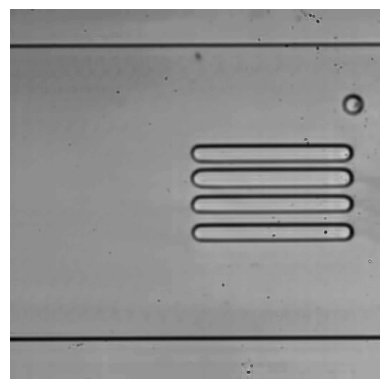

In [23]:
import matplotlib.pyplot as plt

plt.imshow(background, cmap='gray')
plt.axis('off')
plt.show()

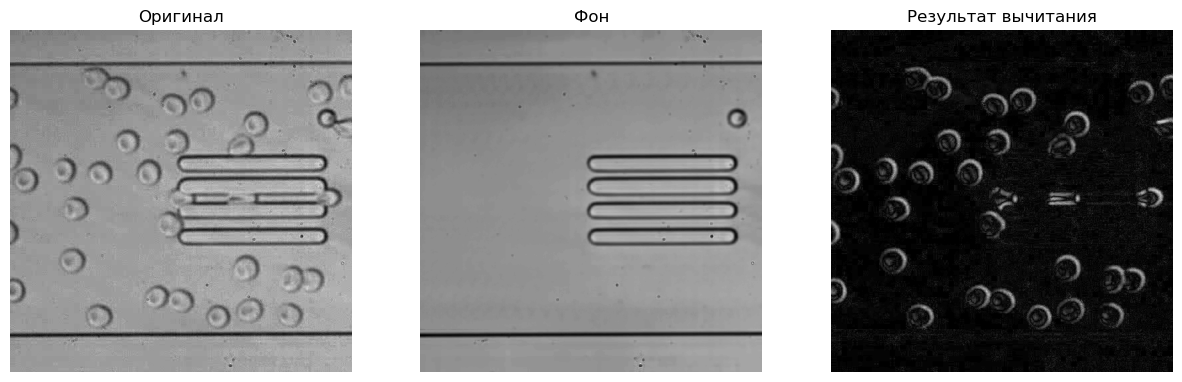

In [17]:

cap = cv2.VideoCapture("Videos/Video_S1_Dylan_RBC_deformability.mp4")
ret, frame = cap.read()
cap.release()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

subtracted = cv2.absdiff(gray, background)

# Показываем результат
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(background, cmap='gray')
plt.title('Фон')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtracted, cmap='gray')
plt.title('Результат вычитания')
plt.axis('off')
plt.show()